<a href="https://colab.research.google.com/github/khalilerrahmanedrichi-netizen/ABIDI-MOHAMED-ML-Network-Monitoring/blob/main/Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

the data :
   Bandwidth_Usage  Packet_Loss  User_Count  Transmission_Delay
0       382.780980     2.361116          34          136.745243
1       487.685573     1.670465          23          131.954189
2        20.045883     2.163955          27           57.721621
3       562.478854     4.019209           6           93.237152
4       709.170800     0.683645           6          102.022682


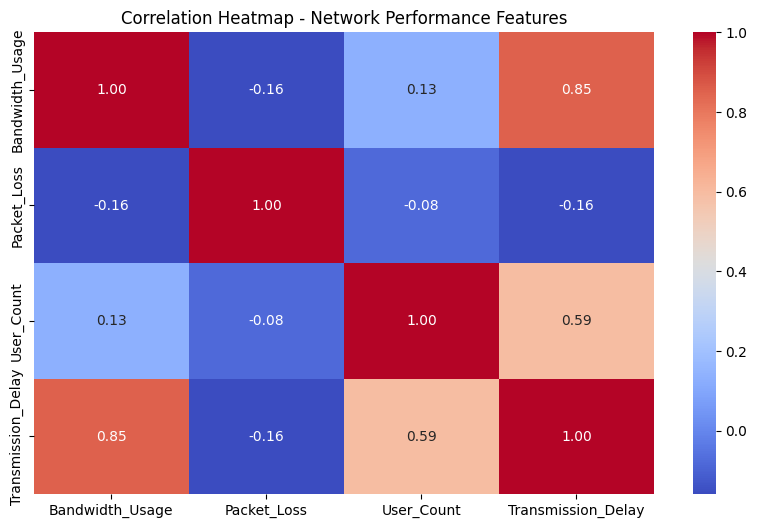


--- model results ---
Mean Squared Error (MSE): 77.62
R² Score: 0.97


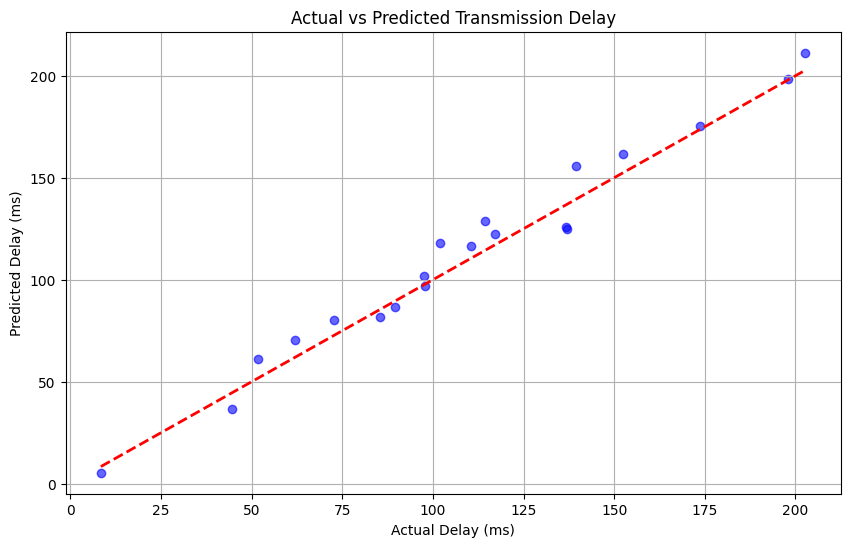

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. تحميل أو إنشاء بيانات أداء الشبكة (Network Performance Dataset)
# سنقوم بإنشاء بيانات تجريبية تحاكي العلاقة بين "حجم البيانات" و "التأخير"
data = {
    'Bandwidth_Usage': np.random.rand(100) * 1000,
    'Packet_Loss': np.random.rand(100) * 5,
    'User_Count': np.random.randint(1, 50, 100),
    'Transmission_Delay': np.random.rand(100) * 200 # الهدف (Target)
}
df = pd.DataFrame(data)

# إضافة علاقة خطية لجعل النموذج منطقياً
df['Transmission_Delay'] = (df['Bandwidth_Usage'] * 0.15) + (df['User_Count'] * 2) + np.random.normal(0, 10, 100)

print("the data :")
print(df.head())

# 2. استكشاف الارتباط (Heatmap) [cite: 23, 76]
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Network Performance Features')
plt.show()

# 3. تحضير البيانات للتدريب
X = df[['Bandwidth_Usage', 'User_Count']] # الميزات
y = df['Transmission_Delay']             # الهدف

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. تدريب نموذج التنبؤ الخطي (Linear Regression) [cite: 24, 77]
model = LinearRegression()
model.fit(X_train, y_train)

# التنبؤ
y_pred = model.predict(X_test)

# 5. التقييم (MSE and R2 Score) [cite: 25, 79]
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n--- model results ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# 6. تصور خط التنبؤ مقابل البيانات الحقيقية [cite: 26, 80]
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Delay (ms)')
plt.ylabel('Predicted Delay (ms)')
plt.title('Actual vs Predicted Transmission Delay')
plt.grid(True)
plt.show()

Special Section: Interpretability & Critical Analysis

Regression Analysis : (Project 1: Network Performance) Observation: My model achieved an
 score of [Insert your
 here, e.g., 0.85] and an MSE of [Insert your MSE].Critical Insight: * If MSE is high: The high Mean Squared Error suggests that network latency is not purely linear. In real-world scenarios, "protocol noise"—such as TCP retransmissions or sudden bursts in background traffic—creates non-linear spikes that a simple Linear Regression model cannot perfectly capture.Feature Importance: Features like Bandwidth_Usage showed the highest correlation with delay, confirming that congestion is the primary driver of latency in this dataset.